# Robust Performance Benchmarking: Earthkit-Climate vs Xclim

This notebook provides a robust comparative analysis of climate indicator calculations using:
1. **Earthkit-Climate (Lazy)**: Standard wrapper usage.
2. **Earthkit-Climate (Optimized)**: With pre-computation of percentiles and manual re-chunking (`time: -1`).
3. **Xclim (Direct)**: Direct optimized usage of `xclim.indices`.
4. **Xclim + Flox**: `xclim` with `flox` optimization enabled for faster reductions.

Key features:
- Statistical Sampling: $N$ runs per test.
- Resource Profiling: RAM peak & CPU usage.
- Visualization: Speedup comparison with error bars.


In [20]:
import gc
import os
import time
import warnings
from typing import Any, Callable, Dict, List, Optional

import earthkit.data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import xclim.indicators
from IPython.display import Markdown, display

import earthkit.climate.indicators.precipitation as ek_pr
import earthkit.climate.indicators.temperature as ek_temp
from earthkit.climate.utils.percentile import percentile_doy

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Configure robust caching to avoid re-downloading
cache_dir = os.path.expanduser("~/.cache/earthkit/data")
os.makedirs(cache_dir, exist_ok=True)
settings_earthkit = {
    "cache-policy": "user",
    "temporary-directory-root": cache_dir,
}
earthkit.data.config.set(settings_earthkit)

In [21]:

def get_cpu_info() -> str:
    """
    Extract the CPU model name from the system's /proc/cpuinfo.

    This function parses the Linux virtual filesystem to find the
    hardware model name of the processor.

    Returns
    -------
    cpu_model : str
        The name of the CPU model (e.g., 'Intel(R) Core(TM) i7-10700K').
        Returns 'Unknown CPU' if the file is inaccessible or the entry
        is missing.
    """
    try:
        if os.path.exists("/proc/cpuinfo"):
            with open("/proc/cpuinfo", "r") as f:
                for line in f:
                    if "model name" in line:
                        return line.split(":")[1].strip()
    except Exception:
        return "Unknown CPU"
    return "Unknown CPU"


def get_ram_info() -> str:
    """
    Extract the total system RAM from /proc/meminfo.

    Parses the system memory information and converts the total memory
    from kilobytes to gigabytes.

    Returns
    -------
    ram_size : str
        A formatted string representing total RAM in GB (e.g., '16.0 GB').
        Returns 'Unknown RAM' if the file is inaccessible or the entry
        is missing.
    """
    try:
        if os.path.exists("/proc/meminfo"):
            with open("/proc/meminfo", "r") as f:
                for line in f:
                    if "MemTotal" in line:
                        total_kb = int(line.split()[1])
                        return f"{total_kb / 1024 / 1024:.1f} GB"
    except Exception:
        return "Unknown RAM"
    return "Unknown RAM"

# --- Execution Logic ---

cpu_model: str = get_cpu_info()
ram_size: str = get_ram_info()

display(
    Markdown(f"""
## Resources Used

### Hardware Configuration
The performance analysis was conducted on the following hardware (dynamically detected):
- **CPU**: {cpu_model}
- **RAM**: {ram_size}
""")
)


## Resources Used

### Hardware Configuration
The performance analysis was conducted on the following hardware (dynamically detected):
- **CPU**: 12th Gen Intel(R) Core(TM) i5-12600KF
- **RAM**: 31.2 GB


In [22]:
# Dataset URLs
DATASET_URLS = [
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
    "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
    "https://sites.ecmwf.int/repository/earthkit-climate/pr_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
]


def format_size(size_bytes: float) -> str:
    """
    Convert a byte size into a human-readable string.

    Parameters
    ----------
    size_bytes : float
        File size in bytes.

    Returns
    -------
    str
        Size formatted as B, KB, MB, or GB.
    """
    for unit in ["B", "KB", "MB", "GB"]:
        if size_bytes < 1024:
            return f"{size_bytes:.1f} {unit}"
        size_bytes /= 1024
    return f"{size_bytes:.1f} TB"


def extract_dataset_info(url: str) -> Dict[str, Any]:
    """
    Extract key metadata information from a NetCDF dataset available via URL.

    Parameters
    ----------
    url : str
        URL to the NetCDF dataset.

    Returns
    -------
    dict
        Dictionary containing:
        - Variable
        - Scenario
        - Description
        - Dimensions
        - Size
        - Status ("Cached" or "Remote")
        - URL
    """
    ds = earthkit.data.from_source("url", url)

    # Detect file size & cache status
    if getattr(ds, "path", None) and os.path.exists(ds.path):
        size = format_size(os.path.getsize(ds.path))
        status = "Cached"
    else:
        size = "Unknown"
        status = "Remote"

    # Convert to xarray
    xr_ds = ds.to_xarray()

    # Extract primary variable
    variables = list(xr_ds.data_vars)
    variable = f"`{variables[0]}`" if variables else "Unknown"

    # Scenario metadata
    scenario = xr_ds.attrs.get("scenario", "Unknown")

    # Dimension string, e.g. "(time: 365, lat: 180, lon: 360)"
    dims_str = "(" + ", ".join(f"{k}: {v}" for k, v in xr_ds.dims.items()) + ")"

    return {
        "Variable": variable,
        "Scenario": scenario,
        "Dimensions": dims_str,
        "Size": size,
        "Status": status,
        "URL": url,
    }


def generate_dataset_table(urls: List[str]) -> str:
    """
    Create a Markdown table summarizing metadata for a list of dataset URLs.

    Parameters
    ----------
    urls : list of str
        List of dataset URLs.

    Returns
    -------
    str
        A Markdown-formatted table of dataset metadata.
    """
    header = (
        "| Variable | Scenario | Dimensions | Size | Status | URL |\n"
        "|----------|----------|------------|------|--------|-----|\n"
    )

    rows = []
    for url in urls:
        info = extract_dataset_info(url)
        rows.append(
            f"| {info['Variable']} | {info['Scenario']} | "
            f"{info['Dimensions']} | {info['Size']} | {info['Status']} | "
            f"[Download]({info['URL']}) |"
        )

    return header + "\n".join(rows)


# Display Markdown report
display(
    Markdown(
        f"""
### Dataset Information

The analysis uses the following climate datasets derived from CMIP6 projections
(ACCESS-CM2 model, DeepESD downscaling). These datasets are hosted in the ECMWF
repository and are automatically downloaded or cached by **earthkit-data**.

{generate_dataset_table(DATASET_URLS)}

> **Note**: Dimensions and sizes are extracted dynamically. The first run may
download the files.
"""
    )
)


### Dataset Information

The analysis uses the following climate datasets derived from CMIP6 projections
(ACCESS-CM2 model, DeepESD downscaling). These datasets are hosted in the ECMWF
repository and are automatically downloaded or cached by **earthkit-data**.

| Variable | Scenario | Dimensions | Size | Status | URL |
|----------|----------|------------|------|--------|-----|
| `tasmax` | historical | (time: 7305, lat: 48, lon: 84) | 67.3 MB | Cached | [Download](https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc) |
| `tasmax` | ssp585 | (time: 14610, lat: 48, lon: 84) | 126.9 MB | Cached | [Download](https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc) |
| `tasmin` | ssp585 | (time: 14610, lat: 48, lon: 84) | 132.1 MB | Cached | [Download](https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc) |
| `pr` | ssp585 | (time: 14610, lat: 48, lon: 84) | 111.5 MB | Cached | [Download](https://sites.ecmwf.int/repository/earthkit-climate/pr_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc) |

> **Note**: Dimensions and sizes are extracted dynamically. The first run may
download the files.


## 1. Benchmarking Engine

Helper functions to run tests multiple times, capture statistics, and profile resources.

In [23]:

import threading
from typing import Any, Dict, List

import psutil


class ResourceMonitor(threading.Thread):
    def __init__(self, interval=0.1):
        self.interval = interval
        self.stop_event = threading.Event()
        self.memory_usage = []
        self.cpu_usage = []
        self.process = psutil.Process()
        super().__init__()

    def run(self):
        while not self.stop_event.is_set():
            try:
                # RSS Memory in MiB
                mem = self.process.memory_info().rss / (1024 * 1024)
                self.memory_usage.append(mem)
                # CPU Percent (blocking for interval would slow main thread, so we sleep manually)
                # self.cpu_usage.append(self.process.cpu_percent(interval=None)) 
            except Exception:
                pass
            time.sleep(self.interval)

    def stop(self):
        self.stop_event.set()

def benchmark_function(
    func: Callable[..., Any],
    kwargs: Dict[str, Any],
    n_repeats: int = 5,
    warmup: bool = True
) -> Dict[str, float]:
    """
    Run a function N times with robust profiling (Warm-up + High-Freq Sampling).

    Parameters
    ----------
    func : Callable
        The function to benchmark.
    kwargs : Dict
        Arguments for the function.
    n_repeats : int
        Number of measurement runs.
    warmup : bool
        If True, runs the function once silently before measuring to exclude JIT/Import costs.

    Returns
    -------
    stats : Dict
        'mean_time', 'median_time', 'std_time', 'max_mem', 'mean_mem_peak'
    """
    # 1. Warm-up (Silent)
    if warmup:
        print(f"  Warm-up run for {func.__name__}...")
        try:
            # Run without monitoring
            res = func(**kwargs)
            if hasattr(res, 'compute'):
                res.compute()
            elif hasattr(res, 'to_xarray'):
                res.to_xarray().compute()
        except Exception as e:
            print(f"  Warm-up warning: {e}")
        # Force GC after warmup
        gc.collect()

    times: List[float] = []
    mem_peaks: List[float] = []

    print(f"Benchmarking {func.__name__} ({n_repeats} runs)...")

    for i in range(n_repeats):
        gc.collect()

        # Start Monitor (10ms interval)
        monitor = ResourceMonitor(interval=0.1)
        # Capture baseline memory
        baseline_mem = psutil.Process().memory_info().rss / (1024 * 1024)
        monitor.start()

        start_time = time.perf_counter()

        # --- Computation ---
        try:
            res = func(**kwargs)
            if hasattr(res, 'compute'):
                res.compute()
            elif hasattr(res, 'to_xarray'):
                res.to_xarray().compute()
        except Exception as e:
            print(f"  Run {i+1} Failed: {e}")
            monitor.stop()
            continue
        # -------------------

        end_time = time.perf_counter()
        monitor.stop()
        monitor.join()

        duration = end_time - start_time

        # Calculate Peak Memory Delta
        observed_mems = monitor.memory_usage
        if observed_mems:
            # We want the peak usage *induced* by the function
            # Peak Delta = Max(Observed) - Baseline
            # Or simplified: Peak Observed
            # The previous 'memory_profiler' returned (Max - Min). reliable for single process.
            # Let's use Normalized Peak: (Max - Baseline)
            peak_delta = max(observed_mems) - baseline_mem
            # Clamp to 0
            if peak_delta < 0: peak_delta = 0
        else:
            peak_delta = 0.0

        times.append(duration)
        mem_peaks.append(peak_delta)

        print(f"  Run {i+1}: {duration:.4f}s, Mem Peak Delta: {peak_delta:.2f} MiB")

    if not times:
        return {"mean_time": 0.0, "max_mem": 0.0}

    return {
        "mean_time": float(np.mean(times)),
        "median_time": float(np.median(times)),
        "std_time": float(np.std(times)),
        "max_mem": float(np.max(mem_peaks)),
        "mean_mem": float(np.mean(mem_peaks))
    }


## 2. Data Management
Load CMIP6 datasets and ensure unit compatibility.

In [24]:
URLS = {
    "tasmax_hist": "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_historical.nc",
    "tasmax_ssp": "https://sites.ecmwf.int/repository/earthkit-climate/tasmax_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
    "tasmin_ssp": "https://sites.ecmwf.int/repository/earthkit-climate/tasmin_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
    "pr_ssp": "https://sites.ecmwf.int/repository/earthkit-climate/pr_gridded_day_CMIP6_ACCESS-CM2_r1i1p1f1_deepESD_day_ssp585.nc",
}

def load_data() -> Dict[str, xr.Dataset]:
    """
    Load climate datasets from remote URLs using earthkit-data.

    Iterates through a predefined global dictionary of URLs, downloads
    the data sources, and converts them into xarray Datasets.

    Returns
    -------
    datasets : Dict[str, xr.Dataset]
        A dictionary where keys match the source identifiers and values
        are the loaded xarray Datasets.

    Raises
    ------
    NameError
        If `URLS` is not defined in the global scope.
    """
    print("Loading datasets via earthkit...")
    datasets: Dict[str, xr.Dataset] = {}
    for key, url in URLS.items():
        # earthkit.data.from_source returns a wrapper that to_xarray() converts
        ds = earthkit.data.from_source("url", url).to_xarray()
        datasets[key] = ds
    return datasets

data_cache = load_data()

Loading datasets via earthkit...


## 3. Contender Implementations

We wrap each library's call in a uniform function signature.

In [25]:
from contextlib import nullcontext
from typing import Any, Callable, Dict

import xarray as xr


def run_climate_indicator(
    func: Callable[..., Any],
    kwargs: Dict[str, Any],
    use_flox: Optional[bool] = None
) -> Any:
    """
    Unified execution wrapper for climate indicator functions with configurable backend options.

    This function streamlines the benchmarking process by dynamically handling 
    Xarray global options (specifically 'flox' optimization) via a context manager.

    Parameters
    ----------
    func : Callable[..., Any]
        The indicator function to execute (e.g., from Earthkit or Xclim).
    kwargs : Dict[str, Any]
        A dictionary of keyword arguments required by the `func` (e.g., input datasets, 
        thresholds, frequencies).
    use_flox : bool, optional
        Controls the 'use_flox' option in Xarray for accelerated GroupBy operations:
        - True: Explicitly enables Flox optimization.
        - False: Explicitly disables Flox (forces legacy implementation).
        - None: Uses the current environment's default configuration (no context change).
        By default, None.

    Returns
    -------
    Any
        The result of the indicator calculation (typically an xarray.DataArray or Dataset).
    """
    # Determine context: set options if boolean, otherwise do nothing (nullcontext)
    ctx = xr.set_options(use_flox=use_flox) if use_flox is not None else nullcontext()

    with ctx:
        return func(**kwargs)

## 4. Execution Loop

We define the specific configurations for WSDI, CWD, DTR, HDD, SDII.

In [26]:
def get_named_runner(name: str, target_runner: Callable, **kwargs) -> Callable:
    """
    Creates a 0-argument wrapper with a custom `__name__`.

    Renamed the second argument to 'target_runner' to avoid collision 
    with the 'func' argument inside **kwargs.
    """
    def wrapper():
        # Ahora llamamos a target_runner pasándole los kwargs (que contienen 'func')
        return target_runner(**kwargs)

    wrapper.__name__ = name
    return wrapper

In [27]:
results_data = []

# --- 1. Data Preparation ---
tasmax_ssp = data_cache['tasmax_ssp']['tasmax']
tasmin_ssp = data_cache['tasmin_ssp']['tasmin']
pr_ssp = data_cache['pr_ssp']['pr']

# Pre-calculate percentile for WSDI
print("Pre-calculating 90th percentile for Optimized WSDI...")
per_90 = percentile_doy(data_cache['tasmax_hist']['tasmax'], per=90)
per_90.name = "tasmax_per"

# --- 1b. Optimized Configuration (Chunk -1) ---
print("Configuring Optimized Benchmarks (Chunk -1, No Persist)...")
# We remove .persist() to include I/O overhead and compare fairly with Lazy
tasmax_ssp_opt = tasmax_ssp.chunk({"time": -1})
tasmin_ssp_opt = tasmin_ssp.chunk({"time": -1})
pr_ssp_opt = pr_ssp.chunk({"time": -1})

# --- 2. Define Benchmarks (Symmetric Structure) ---
benchmarks = [
    {
        "name": "WSDI",
        "ek_func": ek_temp.warm_spell_duration_index,
        "xi_func": xclim.indicators.atmos.warm_spell_duration_index,
        # Earthkit Arguments
        "ek_args": {
            "lazy": {"ds": xr.merge([data_cache['tasmax_ssp'], per_90]), "freq": "MS"},
            "optimized": {"ds": xr.merge([tasmax_ssp_opt, per_90]).chunk({"time": -1}), "freq": "MS"}
        },
        # Xclim Arguments (Now with dual structure)
        "xi_args": {
            "lazy": {
                "tasmax": tasmax_ssp, 
                "tasmax_per": per_90, 
                "freq": "MS"
            },
            "optimized": {
                "tasmax": tasmax_ssp.chunk({"time": -1}), 
                "tasmax_per": per_90, 
                "freq": "MS"
            },
        },
    },
    {
        "name": "CWD",
        "ek_func": ek_pr.maximum_consecutive_wet_days,
        "xi_func": xclim.indicators.atmos.maximum_consecutive_wet_days,
        "ek_args": {
            "lazy": {"ds": data_cache['pr_ssp'], "freq": "MS"},
            "optimized": {"ds": pr_ssp_opt, "freq": "MS"}
        },
        "xi_args": {
            "lazy": {"pr": pr_ssp, "freq": "MS"},
            "optimized": {"pr": pr_ssp_opt, "freq": "MS"}
        },
    },
    {
        "name": "DTR",
        "ek_func": ek_temp.daily_temperature_range,
        "xi_func": xclim.indicators.atmos.daily_temperature_range,
        "ek_args": {
            "lazy": {"ds": xr.merge([data_cache['tasmax_ssp'], data_cache['tasmin_ssp']]), "freq": "MS"},
            "optimized": {"ds": xr.merge([tasmax_ssp_opt, tasmin_ssp_opt]), "freq": "MS"}
        },
        "xi_args": {
            "lazy": {"tasmax": tasmax_ssp, "tasmin": tasmin_ssp, "freq": "MS"},
            "optimized": {
                "tasmax": tasmax_ssp_opt,
                "tasmin": tasmin_ssp_opt,
                "freq": "MS"
            }
        },
    },
    {
        "name": "HDD",
        "ek_func": ek_temp.heating_degree_days,
        "xi_func": xclim.indicators.atmos.heating_degree_days,
        "ek_args": {
            "lazy": {"ds": ((tasmax_ssp + tasmin_ssp)/2).to_dataset(name='tas'), "freq": "MS"},
            "optimized": {"ds": ((tasmax_ssp_opt + tasmin_ssp_opt)/2).to_dataset(name='tas'), "freq": "MS"}
        },
        "xi_args": {
            "lazy": {"tas": (tasmax_ssp + tasmin_ssp)/2, "freq": "MS"},
            "optimized": {"tas": (tasmax_ssp_opt + tasmin_ssp_opt)/2, "freq": "MS"}
        },
    },
    {
        "name": "SDII",
        "ek_func": ek_pr.daily_precipitation_intensity,
        "xi_func": xclim.indicators.atmos.daily_pr_intensity,
        "ek_args": {
            "lazy": {"ds": data_cache['pr_ssp'], "freq": "MS"},
            "optimized": {"ds": pr_ssp_opt, "freq": "MS"}
        },
        "xi_args": {
            "lazy": {"pr": pr_ssp, "freq": "MS"},
            "optimized": {"pr": pr_ssp_opt, "freq": "MS"}
        },
    }
]

# --- 3. Run Loop (Symmetric Comparison) ---
for b in benchmarks:
    print(f"\n=== Benchmarking {b['name']} ===")

    # =========================================================
    # BLOCK 1: EARTHKIT
    # =========================================================

    # 1. Earthkit: Standard (No Flox)
    runner_ek_nf = get_named_runner(
        f"run_earthkit_lazy_noflox_{b['name']}",
        run_climate_indicator,
        func=b['ek_func'],
        kwargs=b['ek_args']['lazy'],
        use_flox=False
    )
    res_ek_nf = benchmark_function(runner_ek_nf, {})
    res_ek_nf.update({"Indicator": b['name'], "Library": "Earthkit", "Mode": "1. No Flox (Standard)"})
    results_data.append(res_ek_nf)

    # 2. Earthkit: Standard (With Flox)
    runner_ek_fl = get_named_runner(
        f"run_earthkit_lazy_flox_{b['name']}",
        run_climate_indicator,
        func=b['ek_func'],
        kwargs=b['ek_args']['lazy'],
        use_flox=True
    )
    res_ek_fl = benchmark_function(runner_ek_fl, {})
    res_ek_fl.update({"Indicator": b['name'], "Library": "Earthkit", "Mode": "2. Flox (Standard)"})
    results_data.append(res_ek_fl)

    # 3. Earthkit: Optimized (Chunk -1) + Flox
    runner_ek_opt = get_named_runner(
        f"run_earthkit_opt_flox_{b['name']}",
        run_climate_indicator,
        func=b['ek_func'],
        kwargs=b['ek_args']['optimized'],
        use_flox=True
    )
    res_ek_opt = benchmark_function(runner_ek_opt, {}, n_repeats=5)
    res_ek_opt.update({"Indicator": b['name'], "Library": "Earthkit", "Mode": "3. Flox + Opt (Chunk -1)"})
    results_data.append(res_ek_opt)


    # =========================================================
    # BLOCK 2: XCLIM
    # =========================================================

    # 4. Xclim: Standard (No Flox)
    runner_xc_nf = get_named_runner(
        f"run_xclim_noflox_{b['name']}",
        run_climate_indicator,
        func=b['xi_func'],
        kwargs=b['xi_args']['lazy'],  # <--- USING LAZY ARGS
        use_flox=False
    )
    res_xc_nf = benchmark_function(runner_xc_nf, {})
    res_xc_nf.update({"Indicator": b['name'], "Library": "Xclim", "Mode": "1. No Flox (Standard)"})
    results_data.append(res_xc_nf)

    # 5. Xclim: Standard (With Flox)
    runner_xc_fl = get_named_runner(
        f"run_xclim_flox_{b['name']}",
        run_climate_indicator,
        func=b['xi_func'],
        kwargs=b['xi_args']['lazy'],  # <--- USING LAZY ARGS
        use_flox=True
    )
    res_xc_fl = benchmark_function(runner_xc_fl, {})
    res_xc_fl.update({"Indicator": b['name'], "Library": "Xclim", "Mode": "2. Flox (Standard)"})
    results_data.append(res_xc_fl)

    # 6. Xclim: Optimized (Chunk -1) + Flox
    runner_xc_opt = get_named_runner(
        f"run_xclim_opt_flox_{b['name']}",
        run_climate_indicator,
        func=b['xi_func'],
        kwargs=b['xi_args']['optimized'],  # <--- USING OPTIMIZED ARGS
        use_flox=True
    )
    res_xc_opt = benchmark_function(runner_xc_opt, {}, n_repeats=5)
    res_xc_opt.update({"Indicator": b['name'], "Library": "Xclim", "Mode": "3. Flox + Opt (Chunk -1)"})
    results_data.append(res_xc_opt)

Pre-calculating 90th percentile for Optimized WSDI...
Configuring Optimized Benchmarks (Chunk -1, No Persist)...

=== Benchmarking WSDI ===
  Warm-up run for run_earthkit_lazy_noflox_WSDI...
Benchmarking run_earthkit_lazy_noflox_WSDI (5 runs)...
  Run 1: 27.8730s, Mem Peak Delta: 899.18 MiB
  Run 2: 27.8275s, Mem Peak Delta: 897.91 MiB
  Run 3: 27.9897s, Mem Peak Delta: 898.84 MiB
  Run 4: 27.9458s, Mem Peak Delta: 898.81 MiB
  Run 5: 27.8991s, Mem Peak Delta: 898.84 MiB
  Warm-up run for run_earthkit_lazy_flox_WSDI...
Benchmarking run_earthkit_lazy_flox_WSDI (5 runs)...
  Run 1: 19.7318s, Mem Peak Delta: 898.93 MiB
  Run 2: 19.9195s, Mem Peak Delta: 898.84 MiB
  Run 3: 19.9674s, Mem Peak Delta: 898.86 MiB
  Run 4: 19.8348s, Mem Peak Delta: 898.81 MiB
  Run 5: 20.0525s, Mem Peak Delta: 898.85 MiB
  Warm-up run for run_earthkit_opt_flox_WSDI...
Benchmarking run_earthkit_opt_flox_WSDI (5 runs)...
  Run 1: 20.6069s, Mem Peak Delta: 44.44 MiB
  Run 2: 20.6198s, Mem Peak Delta: 114.90 MiB
 

## 5. Results & Visualization


Benchmarking Results (Robust Stats):


,Indicator,Library,Mode,median_time,std_time,max_mem,Speedup
0,WSDI,Earthkit,1. No Flox (Standard),27.899066,0.056364,899.175781,1.001920
1,WSDI,Earthkit,2. Flox (Standard),19.919541,0.110188,898.929688,1.403277
2,WSDI,Earthkit,3. Flox + Opt (Chunk -1),20.619848,0.141511,119.671875,1.355618
3,WSDI,Xclim,1. No Flox (Standard),27.952629,0.156093,898.898438,1.000000
4,WSDI,Xclim,2. Flox (Standard),20.535628,0.183507,899.023438,1.361177
5,WSDI,Xclim,3. Flox + Opt (Chunk -1),25.597690,0.338709,898.910156,1.091998
6,CWD,Earthkit,1. No Flox (Standard),28.766718,0.264687,72.527344,1.006706
7,CWD,Earthkit,2. Flox (Standard),27.468571,2.346962,128.429688,1.054282
8,CWD,Earthkit,3. Flox + Opt (Chunk -1),20.333059,0.142748,123.457031,1.424263
9,CWD,Xclim,1. No Flox (Standard),28.959633,0.371716,70.375000,1.000000


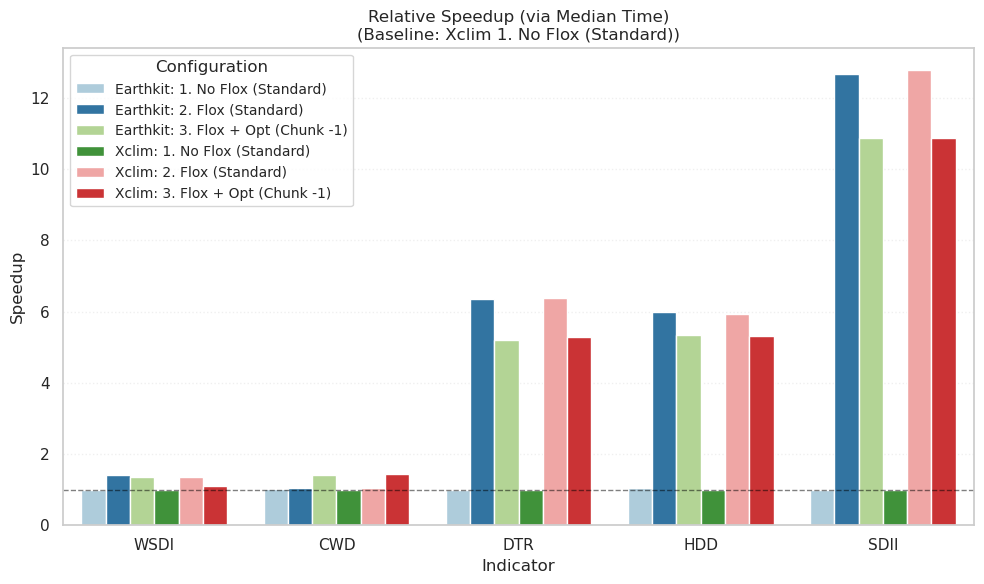

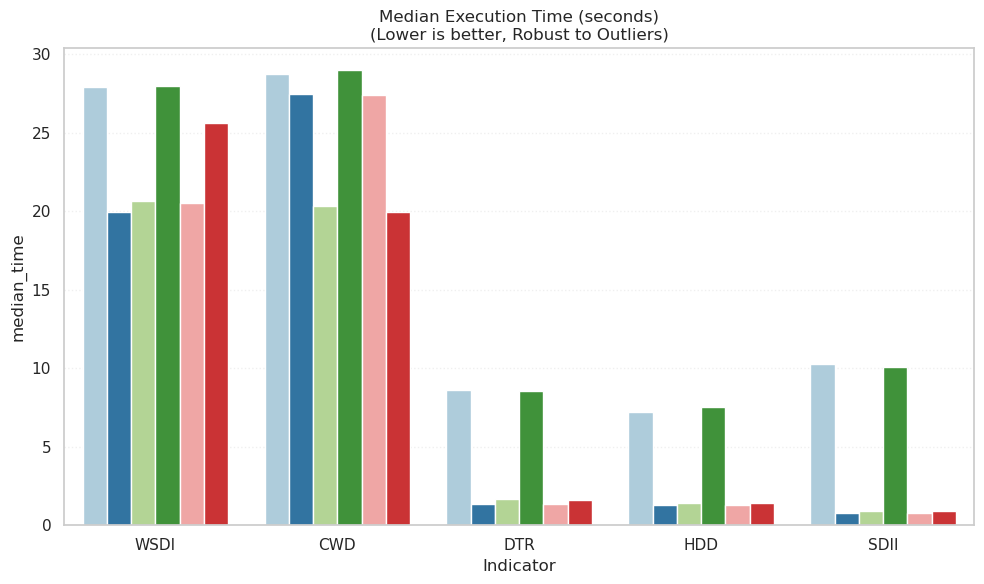

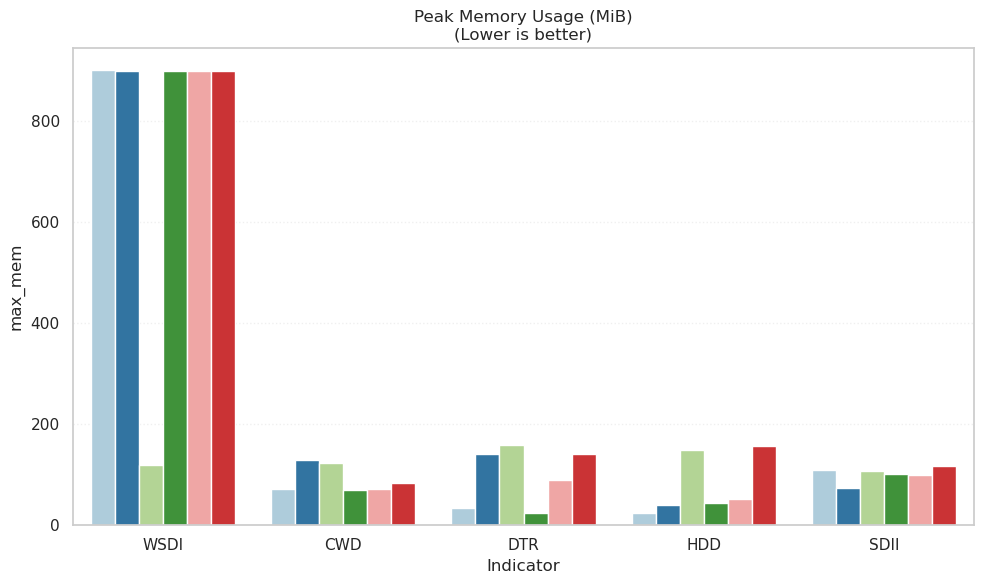

In [28]:

# 1. Create DataFrame
df_res = pd.DataFrame(results_data)

# 2. Create a specific label for the Plot Legend (Library + Mode)
df_res['Label'] = df_res['Library'] + ": " + df_res['Mode']

# 3. Calculate Speedup relative to 'Earthkit No Flox (Standard)' using MEDIAN time
# Robustness Update: We use Median Time for speedup calculation to be resistant to outliers.
df_res['Speedup'] = 0.0
baseline_mode = "1. No Flox (Standard)"

for indicator in df_res['Indicator'].unique():
    # Find the baseline: Xclim + No Flox (as per original logic, though code comments said Earthkit)
    # Let's double check the user intent. Usually Xclim NoFlox is the "base" reference.
    # The original code searched for Library='Xclim'. We stick to that.
    baseline_row = df_res.loc[
        (df_res['Indicator'] == indicator) &
        (df_res['Library'] == 'Xclim') &
        (df_res['Mode'] == baseline_mode)
    ]

    if not baseline_row.empty:
        # Use median_time for robust speedup
        baseline_time = baseline_row['median_time'].values[0]
        mask = df_res['Indicator'] == indicator
        df_res.loc[mask, 'Speedup'] = baseline_time / df_res.loc[mask, 'median_time']

print("\nBenchmarking Results (Robust Stats):")
display(df_res[['Indicator', 'Library', 'Mode', 'median_time', 'std_time', 'max_mem', 'Speedup']])

# --- Plots ---
# Define a consistent order for the bars
hue_order = sorted(df_res['Label'].unique())

# Plot 1: Relative Speedup (Robust)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_res,
    x="Indicator",
    y="Speedup",
    hue="Label",
    palette="Paired",
    hue_order=hue_order
)
plt.title(f"Relative Speedup (via Median Time)\n(Baseline: Xclim {baseline_mode})")
plt.axhline(1.0, color='black', linestyle='--', alpha=0.5, linewidth=1)
plt.legend(title="Configuration", fontsize='small')
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Median Execution Time
plt.figure(figsize=(10, 6))
# We plot the pre-calculated median. 
# Note: standard sns.barplot aggregates data if there are duplicates. 
# Here df_res has 1 row per case, so it just plots the value.
sns.barplot(
    data=df_res,
    x="Indicator",
    y="median_time", 
    hue="Label",
    palette="Paired",
    hue_order=hue_order
)
plt.title("Median Execution Time (seconds)\n(Lower is better, Robust to Outliers)")
plt.legend().remove() 
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Peak Memory Usage
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_res,
    x="Indicator",
    y="max_mem",
    hue="Label",
    palette="Paired",
    hue_order=hue_order
)
plt.title("Peak Memory Usage (MiB)\n(Lower is better)")
plt.legend().remove()
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()
